In [1]:
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["legend.frameon"] = False

In [2]:
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2/(2 * sigma**2)) * 1/(np.sqrt(2 * np.pi) * sigma)

def noise(w):
    lr = 0.1

    return lr * np.tanh(w) * np.random.randn(w.shape[0])  # random noise to simulate variability in plasticity

def normalize(x):
    return x / np.sum(x)

In [3]:
a = np.linspace(0, 180, 500)
mu = 90
sigma = 10
w = gaussian(a, mu, sigma)
c = noise(w)

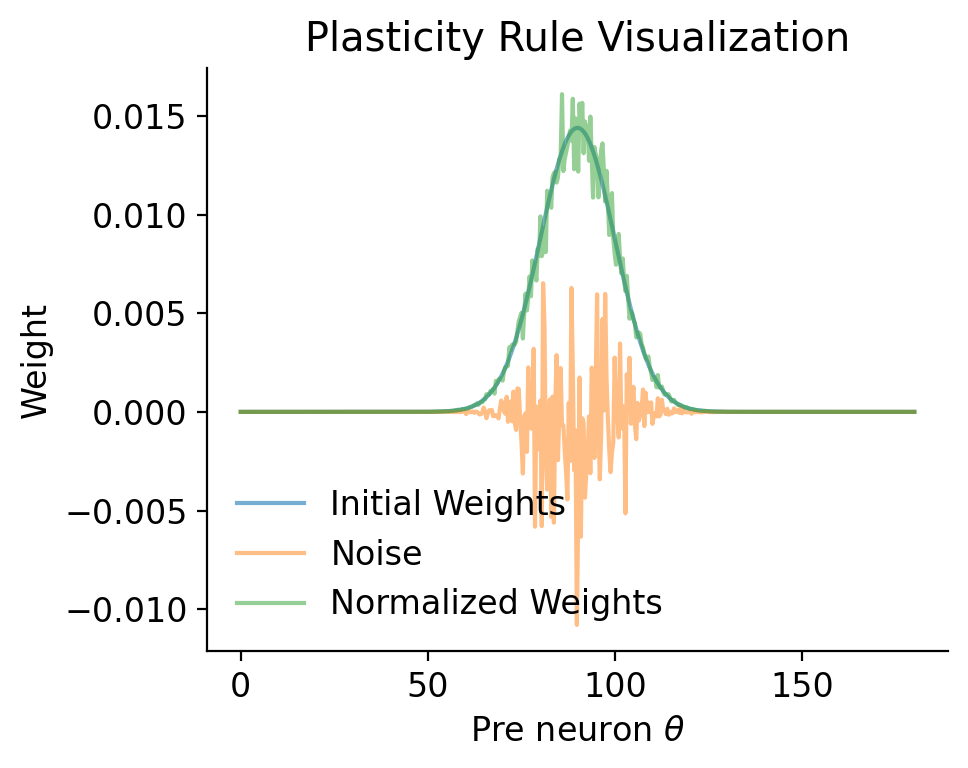

In [4]:
plt.figure(figsize=(5, 4), dpi=200)
plt.plot(a, normalize(w), label='Initial Weights', alpha=0.6)
plt.plot(a, noise(w), label='Noise', alpha=0.5)
plt.plot(a, normalize(w + noise(w)), label='Normalized Weights', alpha=0.5)
plt.xlabel(r'Pre neuron $\theta$')
plt.ylabel('Weight')
plt.title('Plasticity Rule Visualization')
plt.legend()
plt.tight_layout()

In [5]:

# simulate weight update dynamics with noise
pre_nrn_idx = np.linspace(0, 180, 500)
init_w = gaussian(pre_nrn_idx, 90, 10)

n_steps = 1000
n_steps_per_norm = 30

w = init_w.copy()
w_rec = [w]

for step in range(n_steps):
    noise_term = noise(w)
    w += noise_term  # update weights with noise
    if (step + 1) % n_steps_per_norm == 0:
        w = normalize(w)  # normalize weights every n_steps_per_norm steps
    w_rec.append(w.copy())



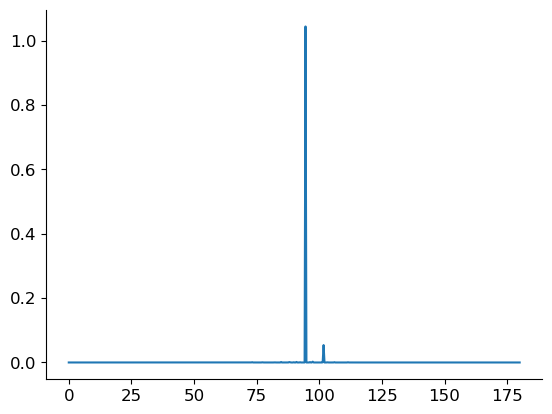

In [6]:
plt.plot(pre_nrn_idx, w)

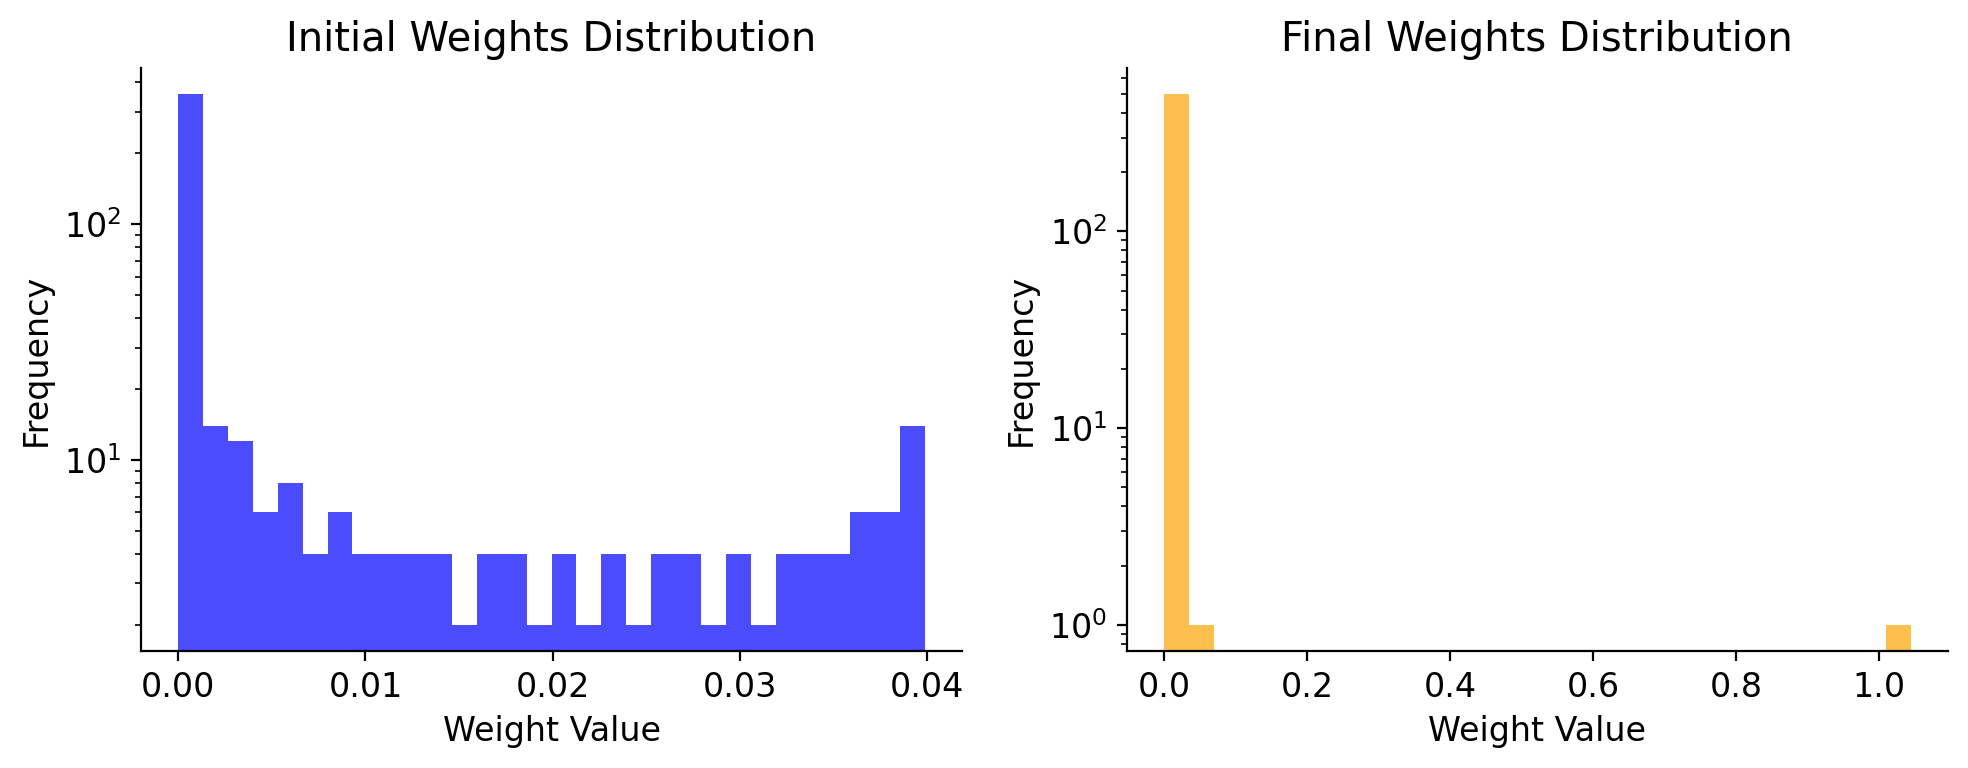

In [13]:
# plot histogram of weights before and after simulation

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=200)
axs[0].hist(init_w, bins=30, alpha=0.7, color='blue', label='Initial Weights')
axs[0].set_title('Initial Weights Distribution')
axs[0].set_xlabel('Weight Value')
axs[0].set_ylabel('Frequency')
axs[0].set_yscale('log')

axs[1].hist(w, bins=30, alpha=0.7, color='orange', label='Final Weights')
axs[1].set_title('Final Weights Distribution')
axs[1].set_xlabel('Weight Value')
axs[1].set_ylabel('Frequency')
axs[1].set_yscale('log')
fig.tight_layout()


MovieWriter imagemagick unavailable; using Pillow instead.


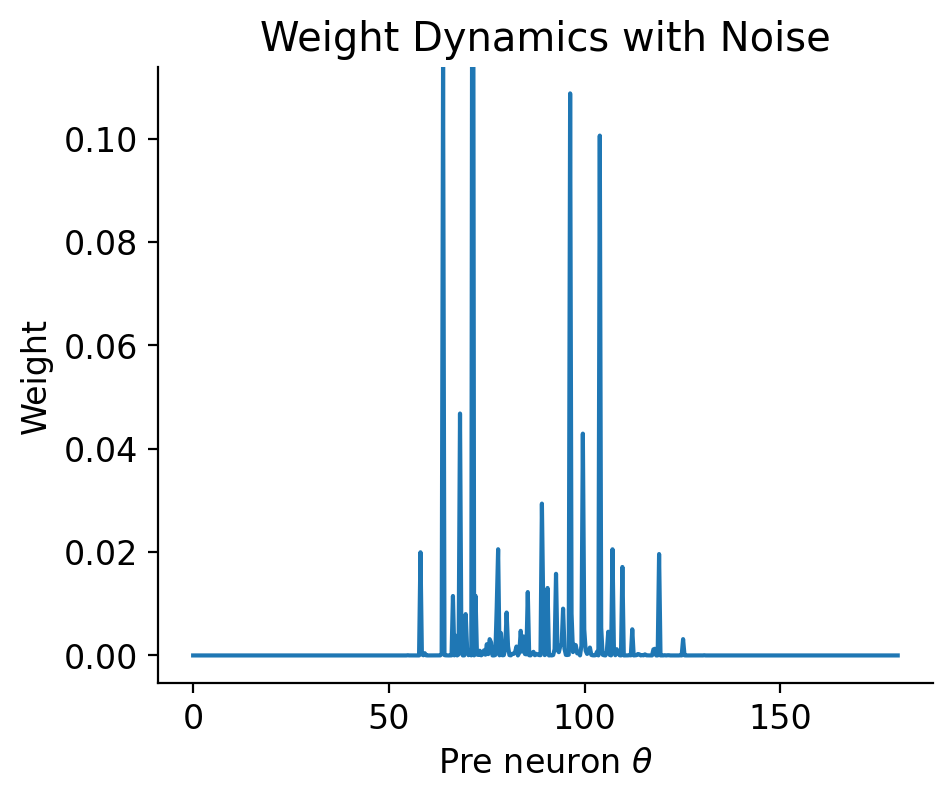

In [77]:
# create animation of weight dynamics

from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
line, = ax.plot(pre_nrn_idx, w_rec[0])
ax.set_xlabel(r'Pre neuron $\theta$')
ax.set_ylabel('Weight')
ax.set_title('Weight Dynamics with Noise')

def init():
    line.set_ydata(w_rec[0])
    return line,

def update(frame):
    line.set_ydata(w_rec[frame])
    return line,

ani = FuncAnimation(fig, update, frames=len(w_rec), init_func=init, blit=True, interval=50)
ani.save('weight_dynamics_with_noise.gif', writer='imagemagick')

In [17]:
# Scenario with weight clipping

# simulate weight update dynamics with noise
pre_nrn_idx = np.linspace(0, 180, 500)
init_w = gaussian(pre_nrn_idx, 90, 10)

n_steps = 1000
n_steps_per_norm = 30

w = init_w.copy()
w_rec = [w]
w_max = 1 * np.max(init_w)  # set maximum weight value

for step in range(n_steps):
    noise_term = noise(w)
    w += noise_term  # update weights with noise
    w = np.clip(w, 0, w_max)  # clip weights to be non-negative
    if (step + 1) % n_steps_per_norm == 0:
        w = normalize(w)  # normalize weights every n_steps_per_norm steps
    w_rec.append(w.copy())


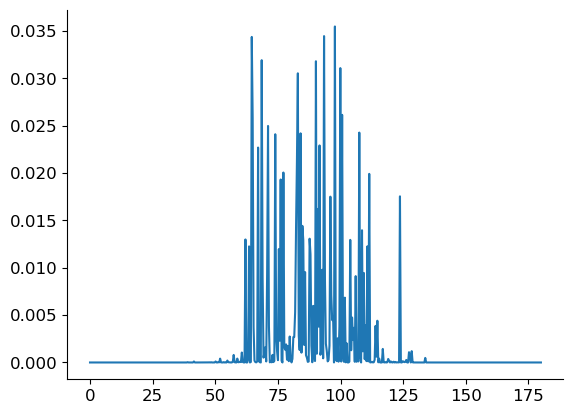

In [18]:
plt.plot(pre_nrn_idx, w_rec[-1])

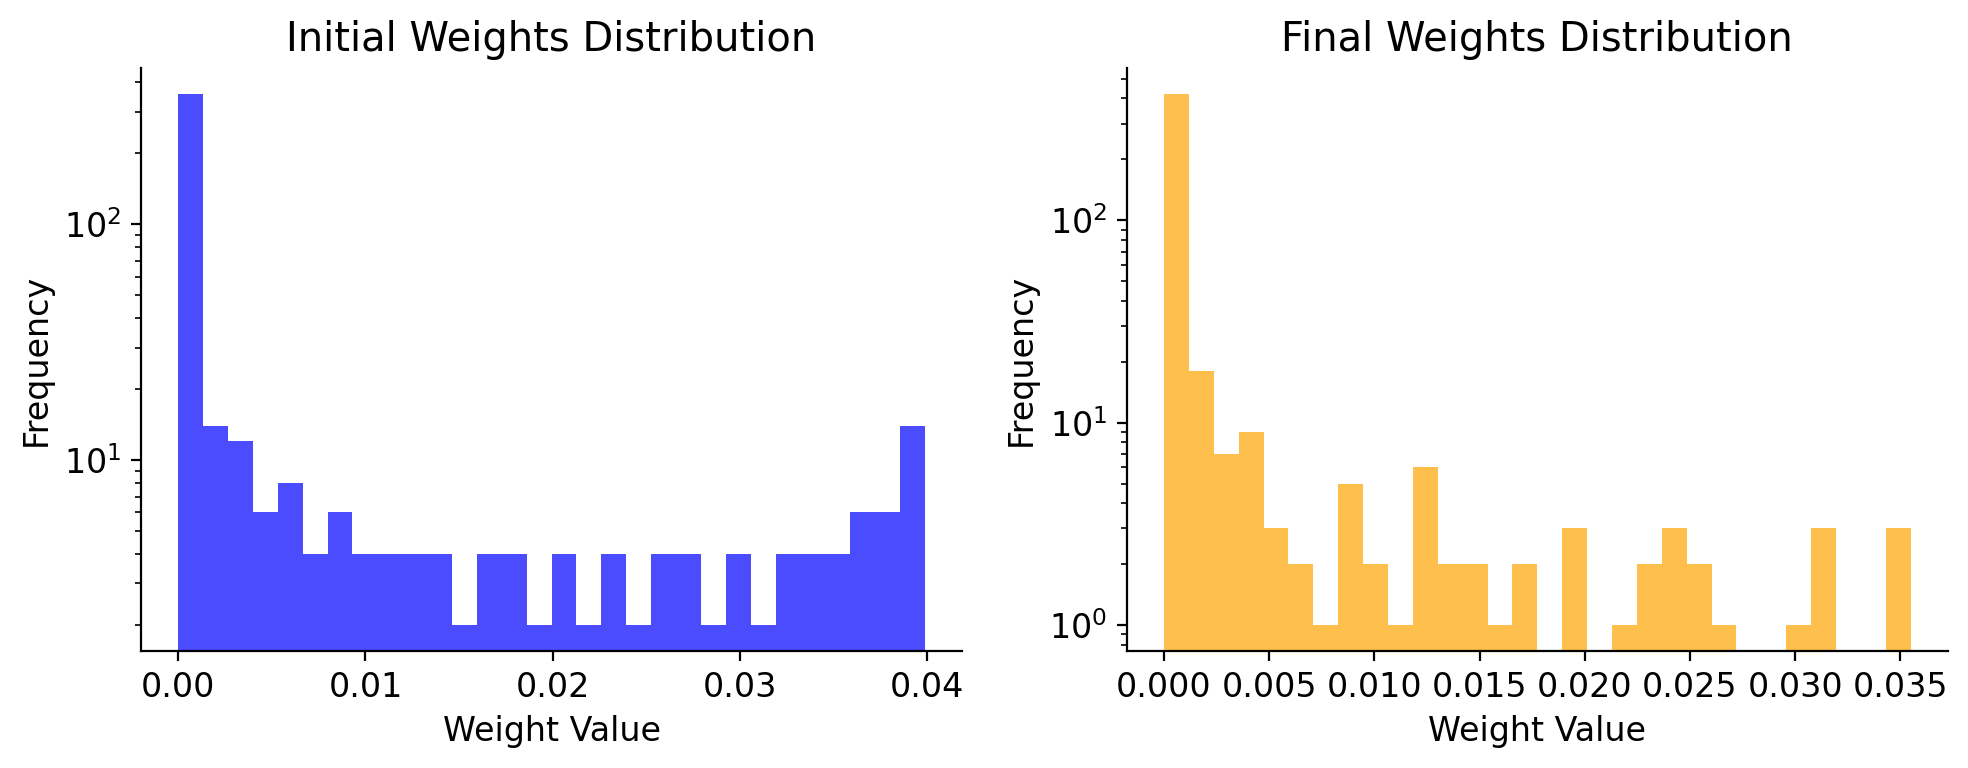

In [19]:
# plot histogram of weights before and after simulation

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=200)
axs[0].hist(init_w, bins=30, alpha=0.7, color='blue', label='Initial Weights')
axs[0].set_title('Initial Weights Distribution')
axs[0].set_xlabel('Weight Value')
axs[0].set_ylabel('Frequency')
axs[0].set_yscale('log')

axs[1].hist(w, bins=30, alpha=0.7, color='orange', label='Final Weights')
axs[1].set_title('Final Weights Distribution')
axs[1].set_xlabel('Weight Value')
axs[1].set_ylabel('Frequency')
axs[1].set_yscale('log')
fig.tight_layout()


In [ ]:
# create animation of weight dynamics

from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
line, = ax.plot(pre_nrn_idx, w_rec[0])
ax.set_xlabel(r'Pre neuron $\theta$')
ax.set_ylabel('Weight')
ax.set_title('Weight Dynamics with Noise')

def init():
    line.set_ydata(w_rec[0])
    return line,

def update(frame):
    line.set_ydata(w_rec[frame])
    return line,

ani = FuncAnimation(fig, update, frames=len(w_rec), init_func=init, blit=True, interval=50)
ani.save('weight_dynamics_with_noise_with_clipping.gif', writer='imagemagick')

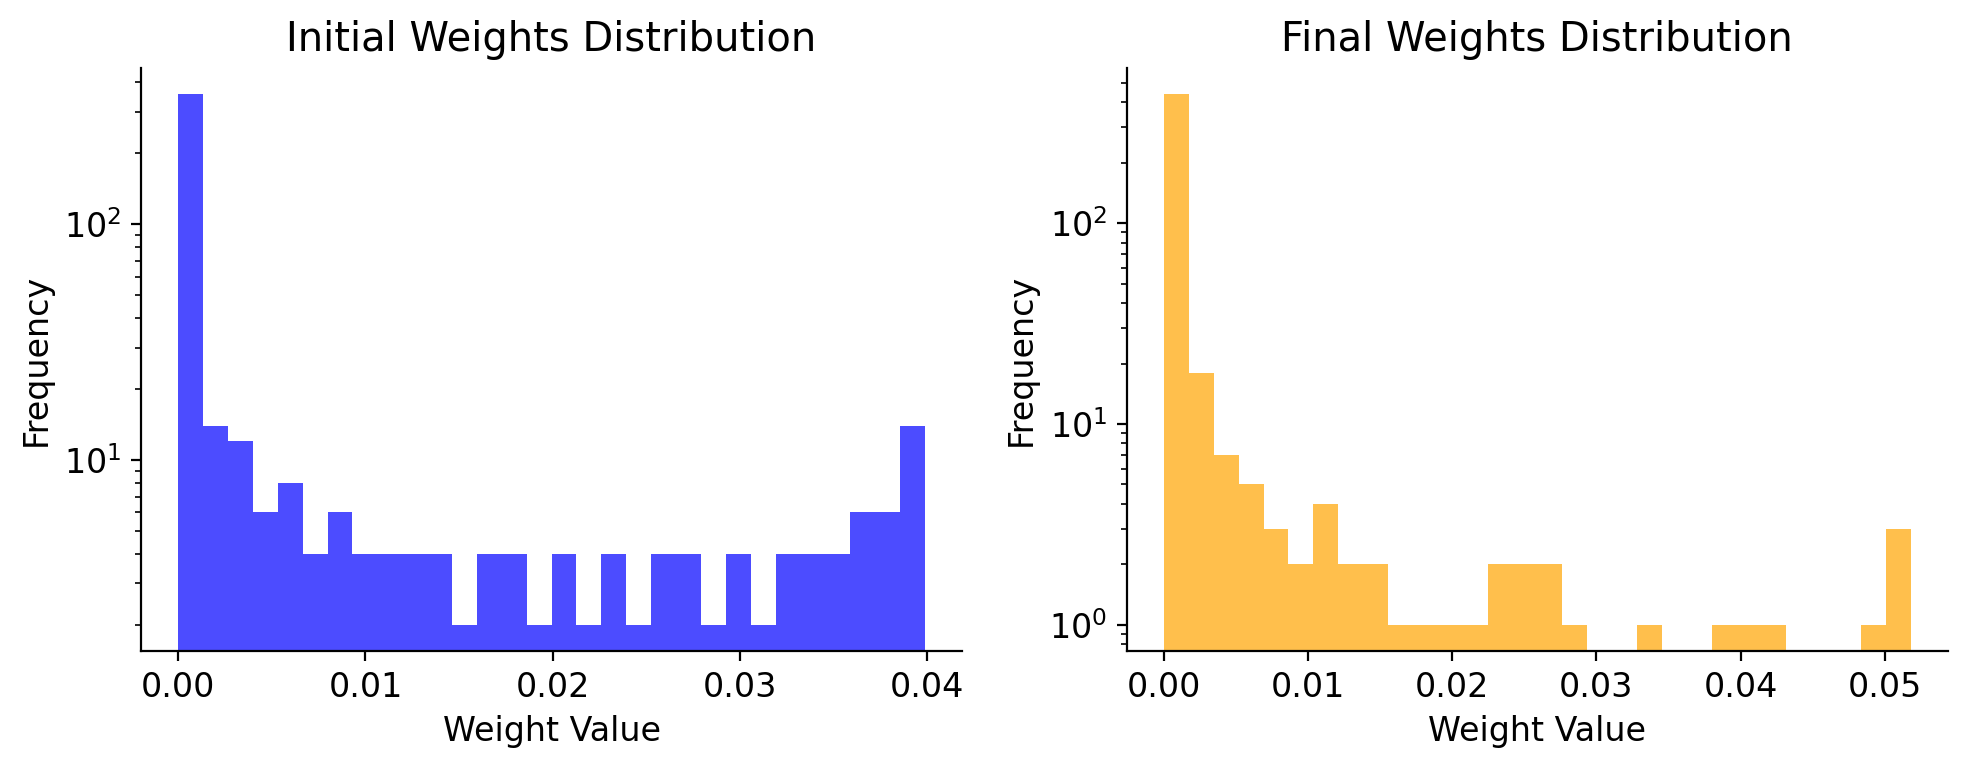